In [1]:

from pathlib import Path
marker = Path('/tmp/quantem-show2d-reopen.z6twqg/all-widgets-run-count.txt')
count = int(marker.read_text()) if marker.exists() else 0
marker.write_text(str(count + 1))

import numpy as np
from quantem.widget import Show2D, Show3D, Show3DSlices

size2 = 256
row2, col2 = np.mgrid[0:size2, 0:size2]
spacing2 = 24
image = np.zeros((size2, size2), dtype=np.float32)
for r0 in np.arange(spacing2 // 2, size2, spacing2):
    for c0 in np.arange(spacing2 // 2, size2, spacing2):
        image += np.exp(-((row2 - r0) ** 2 + (col2 - c0) ** 2) / (2 * 3.0 ** 2))
rng = np.random.default_rng(0)
image += 0.05 * rng.standard_normal(image.shape).astype(np.float32)
image[88:158, 102:172] += 0.7
variants = np.stack([
    image,
    np.fliplr(image),
    image + 0.18 * rng.standard_normal(image.shape).astype(np.float32),
]).astype(np.float32)

depth, size = 24, 96
row, col = np.mgrid[0:size, 0:size]
spacing = 16
sites = np.arange(spacing // 2, size, spacing)
volume = np.zeros((depth, size, size), dtype=np.float32)
for z in range(depth):
    shift = 5.0 * np.sin(2 * np.pi * z / depth)
    for r0 in sites:
        for c0 in sites:
            volume[z] += np.exp(-(((row - r0 - shift) ** 2 + (col - c0) ** 2)) / (2 * 2.2 ** 2))
    volume[z] += 0.25 * np.exp(-(((row - 42) / 18) ** 2 + ((col - (35 + z * 1.2)) / 11) ** 2))
volume = volume.astype(np.float32)


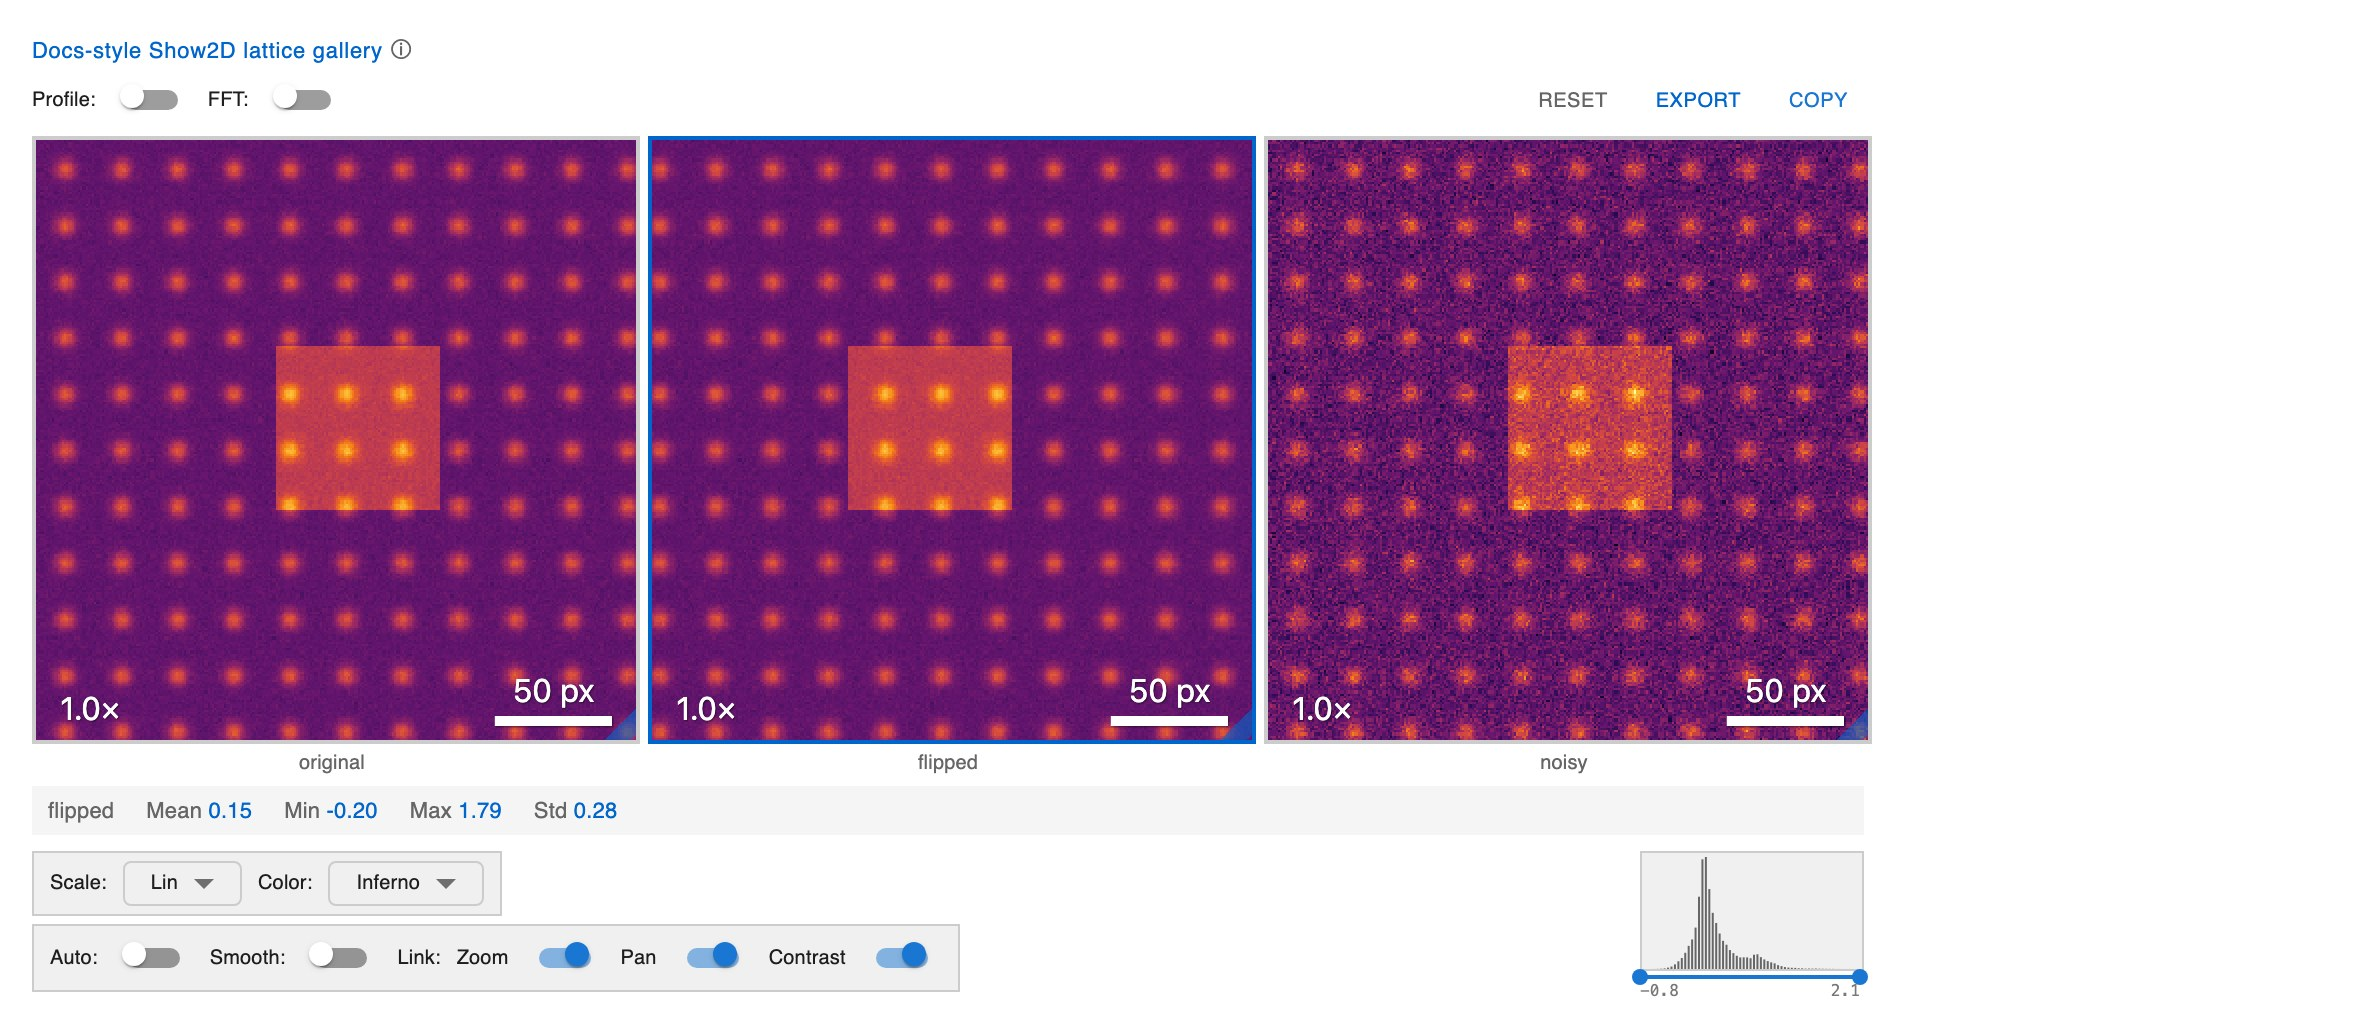

In [2]:

Show2D(
    variants,
    labels=["original", "flipped", "noisy"],
    pixel_size=0.2,
    title="Docs-style Show2D lattice gallery",
    offline=True,
    ncols=3,
    size=300,
    verbose=False,
)


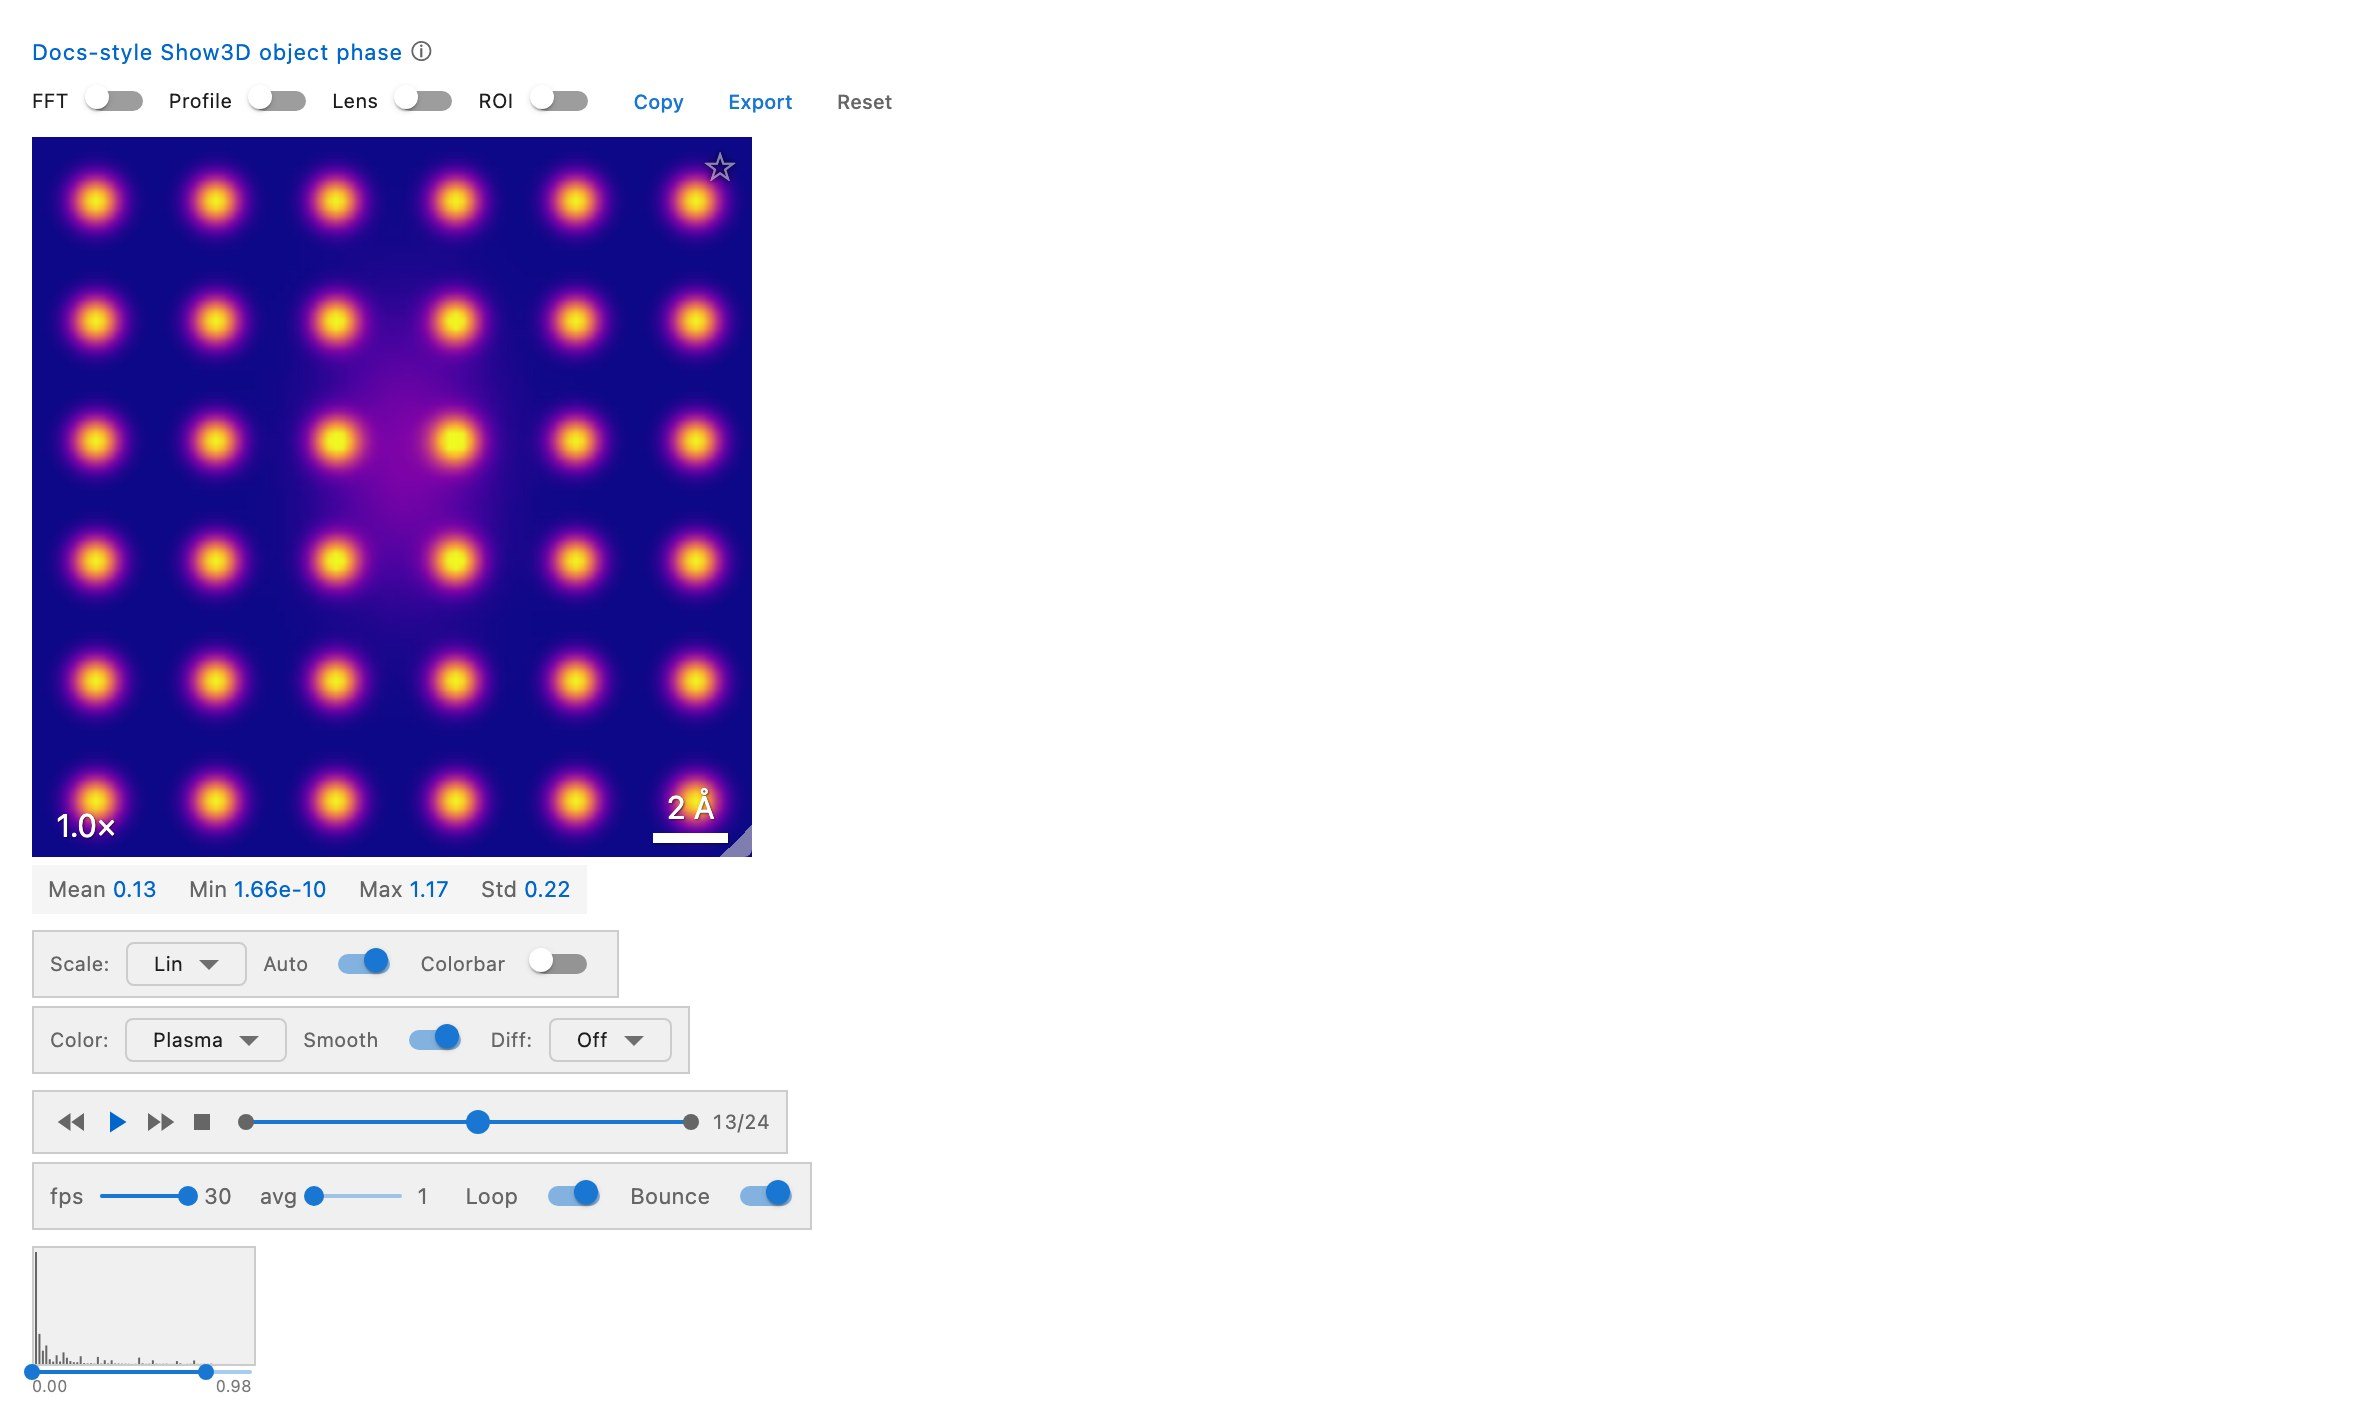

In [3]:

Show3D(
    volume,
    sampling=0.2,
    units="A",
    title="Docs-style Show3D object phase",
    offline=True,
    show_fft=False,
    panel_width_px=360,
)


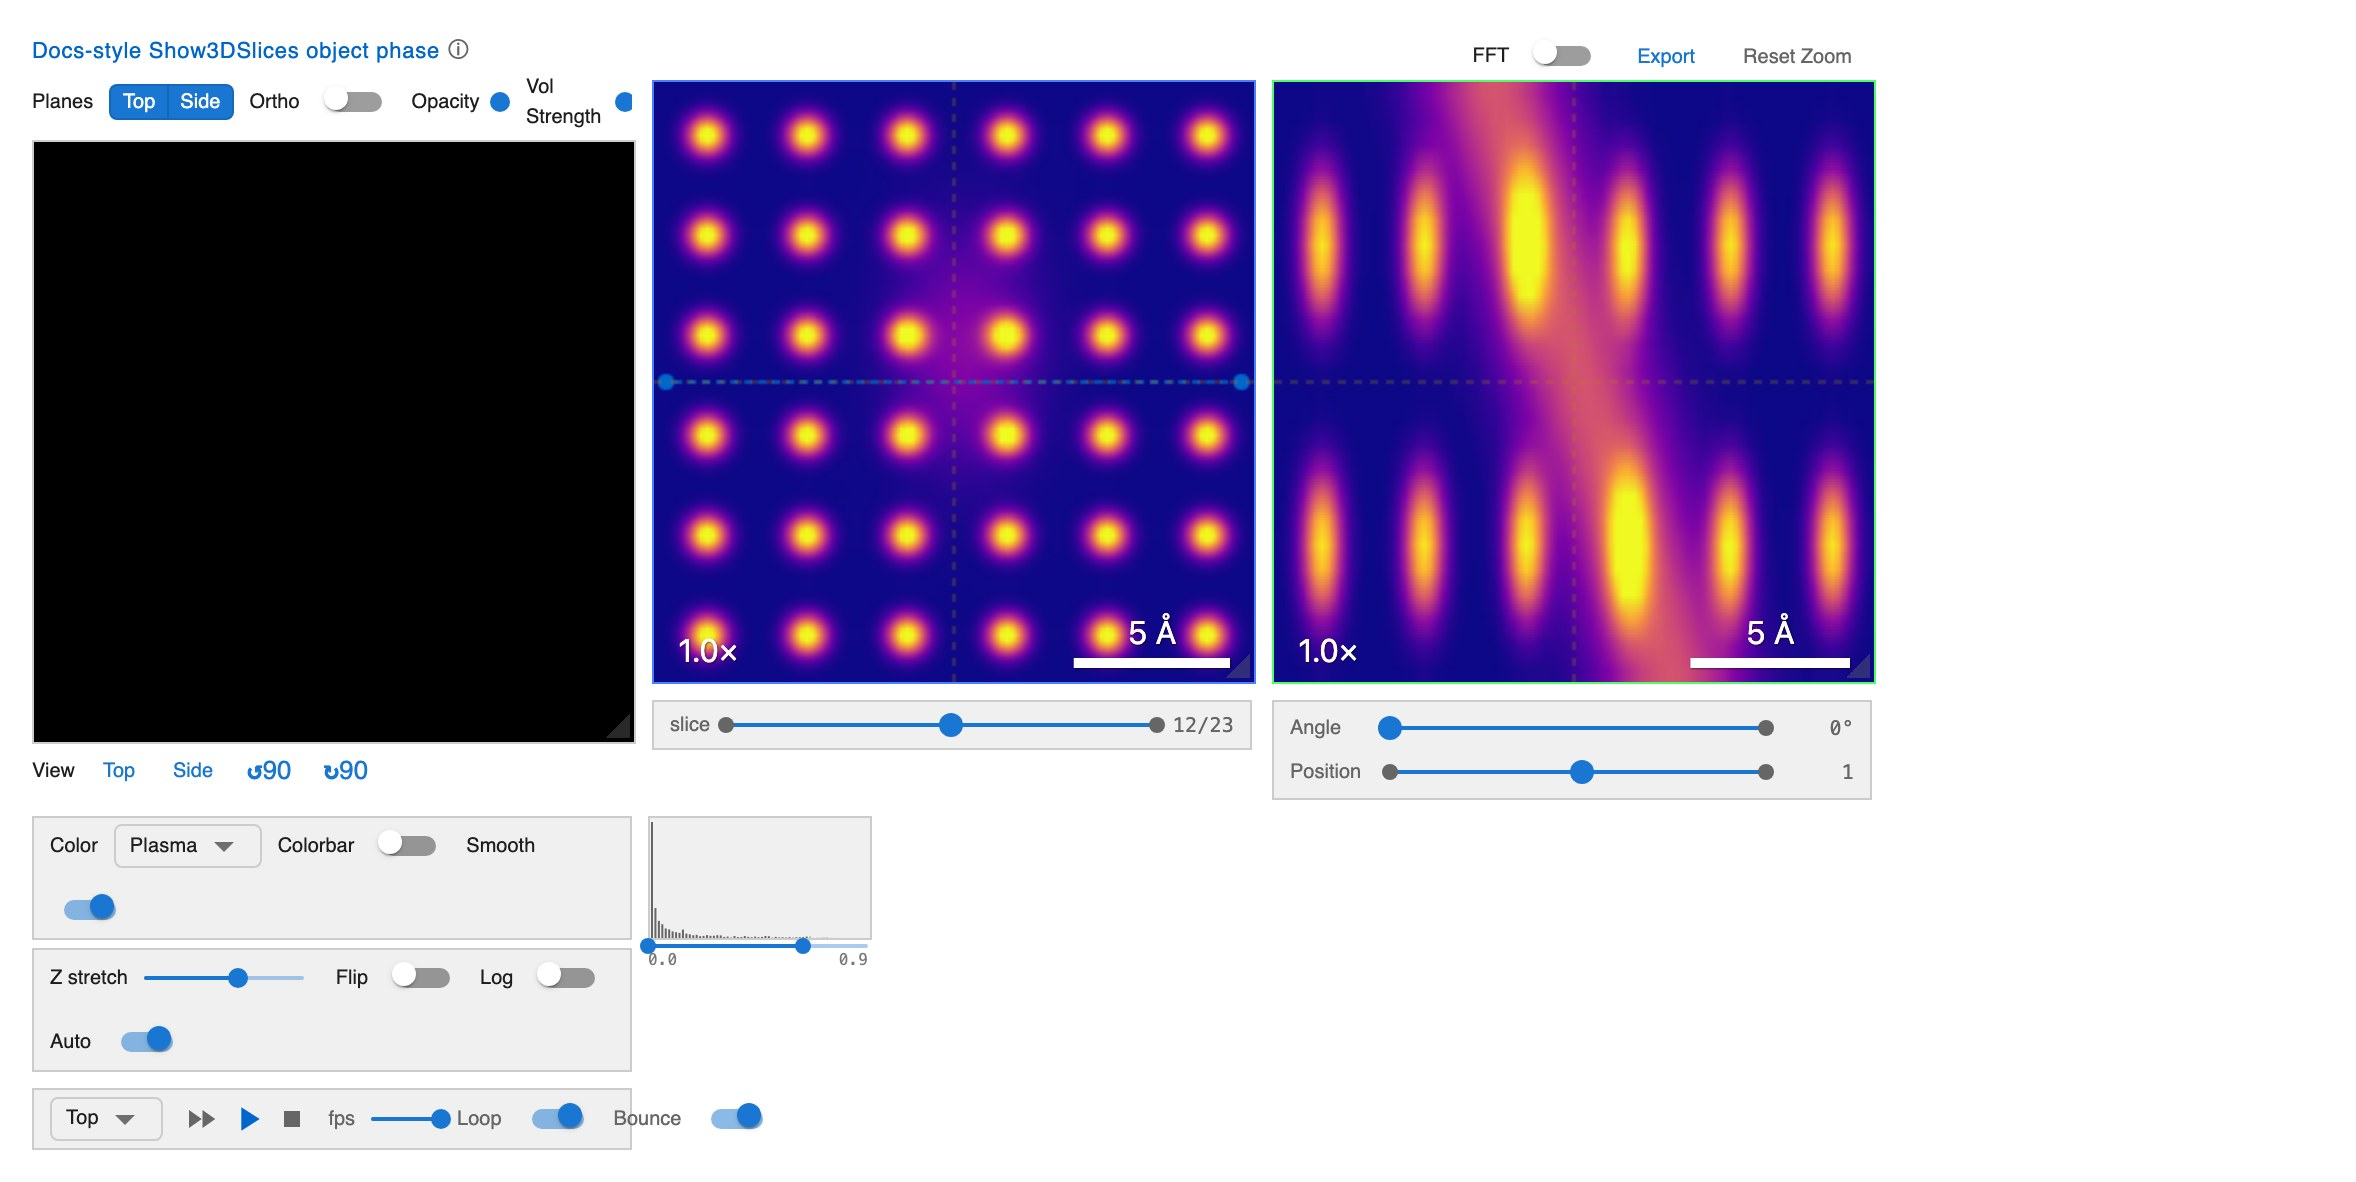

In [4]:

Show3DSlices(
    volume,
    sampling=0.2,
    units="A",
    title="Docs-style Show3DSlices object phase",
    offline=True,
    panel_width_px=300,
)
